# Transfer Learning Tutorial for Polymer Properties

This notebook demonstrates a small transfer-learning experiment for polymer property prediction using the PolyOmics dataset. We treat a large pool of MD-derived polymer data as the source domain, fine-tune on a small fixed target set, and test whether increasing the source pretraining size improves downstream prediction performance.

The experimental idea follows the Sim2Real transfer-learning scaling law discussed by Minami et al. In that paper, a neural network is pretrained on MD simulation data and fine-tuned on experimental polymer property data. The downstream error is analyzed as a function of the source pretraining size `n` using a curve of the form

$$R(n) = D n^{-\alpha} + C.$$

- Dataset: [yhayashi1986/PolyOmics](https://huggingface.co/datasets/yhayashi1986/PolyOmics)
- CSV file: `general_polymers_with_sp_abbe_dynamic-dielectric.csv`
- Paper:
  - [Scaling law of Sim2Real transfer learning in expanding computational materials databases for real-world predictions](https://www.nature.com/articles/s41524-025-01606-5)
  - [Omics-scale polymer computational database transferable to real-world artificial intelligence applications](https://arxiv.org/abs/2511.11626)

Because this tutorial uses only the requested CSV file, it is not a full experimental Sim2Real reproduction. Instead, it creates a self-contained proxy experiment by splitting the same computational dataset into a large source pool and a small target task.

In [2]:
# Install the packages

! pip install pandas numpy scikit-learn torch matplotlib scipy tqdm rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 27.2 MB/s eta 0:00:00


In [ ]:
# load the packages

# ==============================================================================
# ★変更: numpy/torch を import する前に BLAS/OpenMP のスレッド数を明示的に指定する。
#
# 理由: torch.set_num_threads() は PyTorch 自身の演算スレッド数しか制御しない。
# 一方、numpy/scipy/sklearn (SimpleImputer, StandardScaler など) が内部で使う
# OpenBLAS/MKL は torch とは別にスレッド数を自動決定する。Docker で
# `--cpus=N` のように CPU をcgroup制限していても、OpenBLAS/MKL はホスト側の
# 論理CPU数を見て過剰にスレッドを立ててしまうことがあり、これがCPU側の処理
# (前処理・ECFP6計算など)を遅くする一因になり得る。ここで明示的に固定しておく。
#
# 値は実際にコンテナへ割り当てているCPUコア数に合わせて調整すること
# (doc/Dockerfile.ml-gpu の `docker run --cpus=N` の N と合わせるのが基本)。
# ==============================================================================
import os

_N_THREADS = "8"
os.environ.setdefault("OMP_NUM_THREADS", _N_THREADS)
os.environ.setdefault("OPENBLAS_NUM_THREADS", _N_THREADS)
os.environ.setdefault("MKL_NUM_THREADS", _N_THREADS)
os.environ.setdefault("NUMEXPR_NUM_THREADS", _N_THREADS)

from pathlib import Path
import math
import random
import time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import rdFingerprintGenerator
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
# ★変更: DataLoader/TensorDataset は新しい学習ループ(GPU常駐 + vmapバッチ学習)では
# 使わなくなった。cell 19 (外部CSV向けユーティリティ)との互換のためimportだけ残す。
from torch.utils.data import DataLoader, TensorDataset
# ★追加: 複数モデルを1回のGPU呼び出しでまとめて学習・推論するために使う (torch>=2.0)
import copy
from torch.func import functional_call, vmap, grad_and_value, stack_module_state

# Keep the tutorial output clean. Invalid molecules are still counted below.
RDLogger.DisableLog('rdApp.warning')

from tqdm.auto import tqdm

from scipy.optimize import curve_fit
SCIPY_AVAILABLE = True


SEED = 43
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# ★変更: 上で設定したOMP_NUM_THREADSと矛盾しないよう、同じ値を使う
torch.set_num_threads(int(os.environ.get("OMP_NUM_THREADS", min(8, os.cpu_count() or 1))))
print(f'device = {DEVICE}')


## Downloading the dataset (PolyOmics)

In [4]:
DATA_URL = 'https://huggingface.co/datasets/yhayashi1986/PolyOmics/resolve/main/general_polymers_with_sp_abbe_dynamic-dielectric.csv?download=true'
DATA_DIR = Path('data')
DATA_PATH = DATA_DIR / 'general_polymers_with_sp_abbe_dynamic-dielectric.csv'

DATA_DIR.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    print(f'Downloading to {DATA_PATH} ...')

    def reporthook(block_num, block_size, total_size):
        if total_size <= 0:
            return
        downloaded = block_num * block_size
        pct = min(100, downloaded * 100 / total_size)
        if block_num % 250 == 0:
            print(f'  {pct:5.1f}% ({downloaded / 1e6:,.1f} MB / {total_size / 1e6:,.1f} MB)')

    try:
        urllib.request.urlretrieve(DATA_URL, DATA_PATH, reporthook=reporthook)
    except Exception as exc:
        raise RuntimeError(
            'Automatic download failed. Download the CSV from the Hugging Face URL above, '
            f'place it at {DATA_PATH}, and rerun this cell. Original error: {exc}'
        ) from exc
else:
    print(f'Using cached file: {DATA_PATH}')

df = pd.read_csv(DATA_PATH, low_memory=False)
print(df.shape)
df.head()

    0.0% (0.0 MB / 190.4 MB)
    1.1% (2.0 MB / 190.4 MB)
    2.2% (4.1 MB / 190.4 MB)
    3.2% (6.1 MB / 190.4 MB)
    4.3% (8.2 MB / 190.4 MB)
    5.4% (10.2 MB / 190.4 MB)
    6.5% (12.3 MB / 190.4 MB)
    7.5% (14.3 MB / 190.4 MB)
    8.6% (16.4 MB / 190.4 MB)
    9.7% (18.4 MB / 190.4 MB)
   10.8% (20.5 MB / 190.4 MB)
   11.8% (22.5 MB / 190.4 MB)
   12.9% (24.6 MB / 190.4 MB)
   14.0% (26.6 MB / 190.4 MB)
   15.1% (28.7 MB / 190.4 MB)
   16.1% (30.7 MB / 190.4 MB)
   17.2% (32.8 MB / 190.4 MB)
   18.3% (34.8 MB / 190.4 MB)
   19.4% (36.9 MB / 190.4 MB)
   20.4% (38.9 MB / 190.4 MB)
   21.5% (41.0 MB / 190.4 MB)
   22.6% (43.0 MB / 190.4 MB)
   23.7% (45.1 MB / 190.4 MB)
   24.7% (47.1 MB / 190.4 MB)
   25.8% (49.2 MB / 190.4 MB)
   26.9% (51.2 MB / 190.4 MB)
   28.0% (53.2 MB / 190.4 MB)
   29.0% (55.3 MB / 190.4 MB)
   30.1% (57.3 MB / 190.4 MB)
   31.2% (59.4 MB / 190.4 MB)
   32.3% (61.4 MB / 190.4 MB)
   33.3% (63.5 MB / 190.4 MB)
   34.4% (65.5 MB / 190.4 MB)
   35.5% (67.6 

,UUID,monomer_ID,ter_ID_1,ter_ID_2,smiles_list,smiles_ter_1,smiles_ter_2,qm_method,charge,copoly_ratio_list,...,qm_polarizability_sos_xz_monomer1,qm_polarizability_sos_yz_monomer1,refractive_index_sos_486,refractive_index_sos_589,refractive_index_sos_656,refractive_index_sos,abbe_number_sos,efdp_permittivity_real,efdp_permittivity_imaginary,efdp_dielectric_loss_tan
0,afb61c33-4a95-490f-a4a2-5cc881e7d52f,VL1763829,CH3,NaN,*Cc1cccc(*)c1,*C,NaN,wb97m-d3bj,RESP,1,...,0.043204,0.294101,1.161273,1.153173,1.150059,1.138369,13.658753,NaN,NaN,NaN
1,161c084b-eff1-4254-b550-c0d0a58f8caf,VL1763832,CH3,NaN,*c1cccc(C(*)C)c1,*C,NaN,wb97m-d3bj,RESP,1,...,0.285609,-0.761301,1.138071,1.131167,1.128512,1.118541,13.721209,NaN,NaN,NaN
2,c3c1a153-bb79-40c7-898b-180c49d805dc,VL1763834,CH3,NaN,*Cc1cc(C)c(C)cc1*,*C,NaN,wb97m-d3bj,RESP,1,...,0.123472,0.855169,1.124430,1.117811,1.115279,1.105833,12.874704,NaN,NaN,NaN
3,af231a60-f5ae-4302-bac1-ece5c0bd58d3,VL1763836,CH3,NaN,*CCc1ccc(C)cc1CC*,*C,NaN,wb97m-d3bj,RESP,1,...,-0.876402,-1.476312,1.111862,1.105858,1.103565,1.095025,12.757395,NaN,NaN,NaN
4,c68d7e3b-ae38-4415-87f8-f9a31335738c,VL1763839,CH3,NaN,*c1ccc(C(*)C)cc1C,*C,NaN,wb97m-d3bj,RESP,1,...,-0.708231,-1.385708,1.118257,1.112099,1.109738,1.100910,13.158779,NaN,NaN,NaN


In [6]:
# Check label availability for several polymer properties.
# You can change the downstream task after inspecting this table.

PROPERTY_CANDIDATES = [
    'density', 'Cp', 'Cv', 'thermal_conductivity', 'thermal_diffusivity',
    'static_dielectric_const', 'linear_expansion',
    'bulk_modulus', 'self-diffusion', 'Rg',
]

def to_numeric_series(s):
    if pd.api.types.is_bool_dtype(s):
        return s.astype('float32')
    if pd.api.types.is_numeric_dtype(s):
        return s.astype('float32')
    return pd.to_numeric(s.astype(str).str.replace(',', '', regex=False), errors='coerce').astype('float32')

availability = []
for col in PROPERTY_CANDIDATES:
    if col in df.columns:
        y_col = to_numeric_series(df[col])
        availability.append({
            'column': col,
            'n_non_null': int(y_col.notna().sum()),
            'coverage': float(y_col.notna().mean()),
            'mean': float(y_col.mean(skipna=True)) if y_col.notna().any() else np.nan,
            'std': float(y_col.std(skipna=True)) if y_col.notna().any() else np.nan,
        })

availability = pd.DataFrame(availability).sort_values('n_non_null', ascending=False)
availability

,column,n_non_null,coverage,mean,std
0,density,95335,1.000000,1.135705e+00,1.424432e-01
5,static_dielectric_const,95335,1.000000,5.206066e+00,3.158480e+01
9,Rg,95335,1.000000,2.067396e+01,7.509164e+00
1,Cp,95312,0.999759,3.105307e+03,5.825602e+02
6,linear_expansion,95312,0.999759,1.068907e-04,5.792324e-05
2,Cv,95312,0.999759,3.005842e+03,5.382557e+02
7,bulk_modulus,95312,0.999759,3.254309e+09,9.632198e+08
8,self-diffusion,95311,0.999748,7.616685e-11,2.332162e-08
3,thermal_conductivity,81405,0.853884,2.466922e-01,3.101791e-01
4,thermal_diffusivity,81381,0.853632,7.173102e-08,9.382410e-08


In [7]:
# Tutorial default:
# The default uses density for both source pretraining and target fine-tuning.
# This makes the effect of increasing MD source data size easy to observe.
# For a task-transfer variant, try SOURCE_PROPERTY = 'density' and TARGET_PROPERTY = 'bulk_modulus'.

SOURCE_PROPERTY = 'density'
TARGET_PROPERTY = 'bulk_modulus'

if SOURCE_PROPERTY not in df.columns:
    raise ValueError(f'{SOURCE_PROPERTY=} is not in the dataframe')
if TARGET_PROPERTY not in df.columns:
    raise ValueError(f'{TARGET_PROPERTY=} is not in the dataframe')

source_y = to_numeric_series(df[SOURCE_PROPERTY])
target_y = to_numeric_series(df[TARGET_PROPERTY])
print(f'{SOURCE_PROPERTY}: {source_y.notna().sum():,} non-null rows')
print(f'{TARGET_PROPERTY}: {target_y.notna().sum():,} non-null rows')

density: 95,335 non-null rows
bulk_modulus: 95,312 non-null rows


In [ ]:
# Build input features from RDKit ECFP6 fingerprints.
# ECFP6 is implemented as a Morgan fingerprint with radius=3.
# The tutorial uses the polymer repeat-unit SMILES in smiles_list by default because it is compact.
# If smiles_list is unavailable, the code falls back to other SMILES columns in the CSV.

ECFP_RADIUS = 3
ECFP_N_BITS = 2048
SMILES_COLUMN_CANDIDATES = ['smiles_list']
MORGAN_GENERATOR = rdFingerprintGenerator.GetMorganGenerator(radius=ECFP_RADIUS, fpSize=ECFP_N_BITS)

smiles_col = next((col for col in SMILES_COLUMN_CANDIDATES if col in df.columns), None)
if smiles_col is None:
    raise ValueError(f'No SMILES column found. Tried: {SMILES_COLUMN_CANDIDATES}')

print(f'Using SMILES column: {smiles_col}')

def smiles_to_mol(smiles):
    """Parse one SMILES string into an RDKit molecule; return None for missing or invalid entries."""
    if pd.isna(smiles):
        return None
    smiles = str(smiles).strip()
    if not smiles:
        return None
    return Chem.MolFromSmiles(smiles)


def mol_to_ecfp6_array(mol, n_bits=ECFP_N_BITS, radius=ECFP_RADIUS):
    """Convert an RDKit molecule into a dense ECFP6 bit vector as a float32 numpy array."""
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits) if (radius != ECFP_RADIUS or n_bits != ECFP_N_BITS) else MORGAN_GENERATOR
    fp = generator.GetFingerprint(mol)
    arr = np.zeros((n_bits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# ==============================================================================
# ★追加: ECFP6計算はGPUと無関係(RDKitのシングルスレッドCPUループ)で、PolyOmics
# 全体(数万行)を毎回1行ずつ処理するため、ノートブックを再実行するたびに時間が
# かかる原因になりやすい。SMILESそのものは変わらないので、一度計算した結果を
# ディスクにキャッシュし、2回目以降はロードだけで済ませる。
# (SOURCE_PROPERTY/TARGET_PROPERTYや実験設定だけを変えて再実行する場合、
#  fingerprintの再計算は不要なのでキャッシュがそのまま使い回せる)
# ==============================================================================
FP_CACHE_PATH = DATA_DIR / f'ecfp6_r{ECFP_RADIUS}_b{ECFP_N_BITS}.npz'

if FP_CACHE_PATH.exists():
    print(f'Loading cached ECFP6 features from {FP_CACHE_PATH}')
    _fp_cache = np.load(FP_CACHE_PATH)
    fingerprints = _fp_cache['fingerprints']
    valid_fingerprint = _fp_cache['valid_fingerprint']
else:
    fingerprints = np.full((len(df), ECFP_N_BITS), np.nan, dtype=np.float32)
    valid_fingerprint = np.zeros(len(df), dtype=bool)

    for i, smiles in enumerate(tqdm(df[smiles_col].to_numpy(), desc='Calculating ECFP6')):
        mol = smiles_to_mol(smiles)
        if mol is None:
            continue
        fingerprints[i] = mol_to_ecfp6_array(mol)
        valid_fingerprint[i] = True

    np.savez(FP_CACHE_PATH, fingerprints=fingerprints, valid_fingerprint=valid_fingerprint)
    print(f'Saved ECFP6 features to {FP_CACHE_PATH}')

X = pd.DataFrame(
    fingerprints,
    index=df.index,
    columns=[f'ecfp6_{i}' for i in range(ECFP_N_BITS)],
)

print(f'ECFP6 features: {X.shape[1]} bits, {valid_fingerprint.sum():,} valid molecules / {len(df):,} rows')
print(f'Invalid or missing SMILES rows: {(~valid_fingerprint).sum():,}')
X.iloc[:3, :16]

# ==============================================================================
# ★追加: 前処理(欠損値の穴埋め・標準化)をGPU上で行うため、フィンガープリント全体を
# ここで1回だけGPUに転送しておく。以降、repeat/n_sourceが変わるたびに再転送する
# 必要がなくなる(cell 10のfit_preprocessor/transform_Xがこれを直接使う)。
#
# 対応関係の前提: dfとXは単純な0..N-1の連番インデックス(RangeIndex)を共有しているので、
# `df.index`から取り出したtarget_train_idx等の値(=ラベル)は、そのままX_gpuの
# 行位置(=0番目の次元のインデックス)としても使える。
# ==============================================================================
X_gpu = torch.from_numpy(fingerprints).float().to(DEVICE)
print(f'X_gpu: shape={tuple(X_gpu.shape)}, device={X_gpu.device}')



In [9]:
# Experiment settings.
# QUICK_RUN=True is intended for classroom demonstration.
# Set QUICK_RUN=False for a smoother, more paper-like scaling curve.

QUICK_RUN = True

if QUICK_RUN:
    TARGET_TRAIN_SIZE = 256
    TARGET_TEST_SIZE = 1024
    SOURCE_SIZES = [256, 512, 1024, 2048, 4096, 8192, 16384]
    REPEATS = 5
    PRETRAIN_EPOCHS = 20
    FINETUNE_EPOCHS = 60
else:
    TARGET_TRAIN_SIZE = 1024
    TARGET_TEST_SIZE = 2048
    SOURCE_SIZES = [256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536]
    REPEATS = 50
    PRETRAIN_EPOCHS = 40
    FINETUNE_EPOCHS = 100

BATCH_SIZE = 256
PRETRAIN_LR = 1e-3
FINETUNE_LR = 3e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.05
HIDDEN_DIMS = (1024, 512, 256)

print({
    'quick_run': QUICK_RUN,
    'target_train_size': TARGET_TRAIN_SIZE,
    'target_test_size': TARGET_TEST_SIZE,
    'source_sizes': SOURCE_SIZES,
    'repeats': REPEATS,
    'pretrain_epochs': PRETRAIN_EPOCHS,
    'finetune_epochs': FINETUNE_EPOCHS,
})

{'quick_run': True, 'target_train_size': 256, 'target_test_size': 1024, 'source_sizes': [256, 512, 1024, 2048, 4096, 8192, 16384], 'repeats': 5, 'pretrain_epochs': 20, 'finetune_epochs': 60}


Rows with both density and bulk_modulus: 95,312


,count,mean,std,min,25%,50%,75%,max
density,95312.0,1.135689e+00,1.424232e-01,3.880537e-01,1.050889e+00,1.136052e+00,1.218889e+00,2.836631e+00
bulk_modulus,95312.0,3.254309e+09,9.632198e+08,1.463530e+08,2.550009e+09,3.212791e+09,3.912384e+09,1.384723e+10


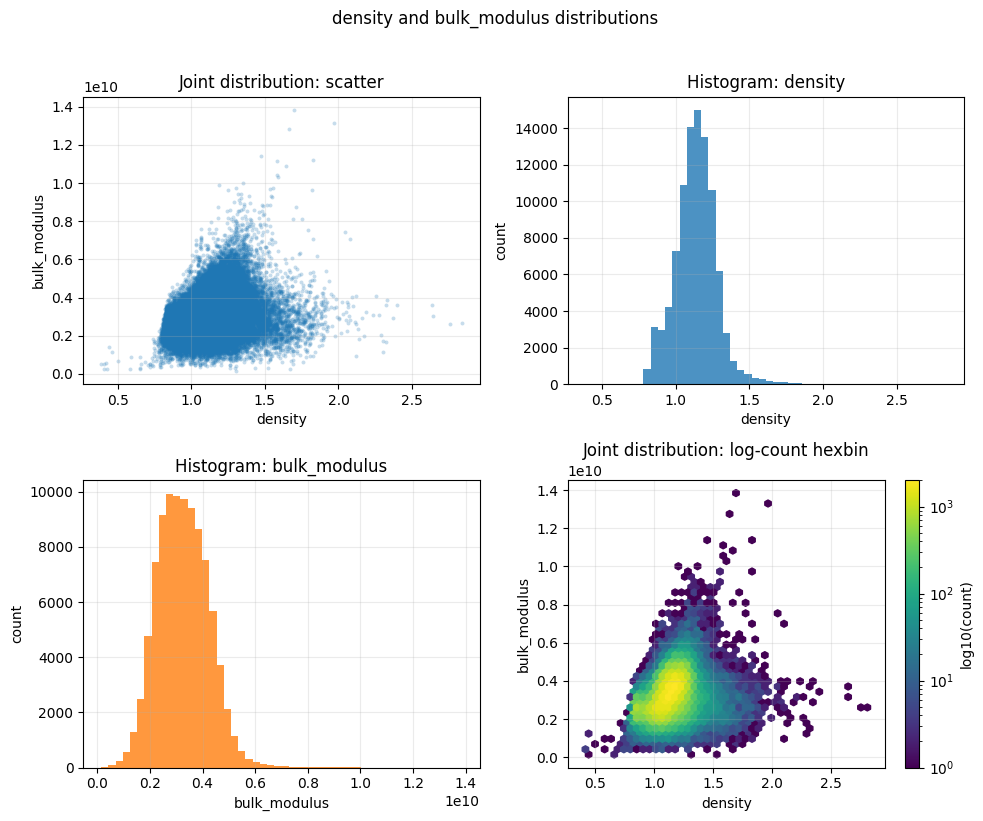

In [10]:
# Property-pair visualization before model training.
# For the current density -> bulk_modulus transfer setting, inspect the marginal and joint distributions.

PAIR_X_PROPERTY = 'density'
PAIR_Y_PROPERTY = 'bulk_modulus'

for col in [PAIR_X_PROPERTY, PAIR_Y_PROPERTY]:
    if col not in df.columns:
        raise ValueError(f'{col} is not in the dataframe')

pair_df = pd.DataFrame({
    PAIR_X_PROPERTY: to_numeric_series(df[PAIR_X_PROPERTY]),
    PAIR_Y_PROPERTY: to_numeric_series(df[PAIR_Y_PROPERTY]),
}).replace([np.inf, -np.inf], np.nan).dropna()

if pair_df.empty:
    raise ValueError(f'No rows have both {PAIR_X_PROPERTY} and {PAIR_Y_PROPERTY}')

print(f'Rows with both {PAIR_X_PROPERTY} and {PAIR_Y_PROPERTY}: {len(pair_df):,}')
display(pair_df.describe().T)

x = pair_df[PAIR_X_PROPERTY].to_numpy()
y = pair_df[PAIR_Y_PROPERTY].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].scatter(x, y, s=8, alpha=0.25, linewidths=0)
axes[0, 0].set_xlabel(PAIR_X_PROPERTY)
axes[0, 0].set_ylabel(PAIR_Y_PROPERTY)
axes[0, 0].set_title('Joint distribution: scatter')
axes[0, 0].grid(alpha=0.25)

axes[0, 1].hist(x, bins=50, color='tab:blue', alpha=0.8)
axes[0, 1].set_xlabel(PAIR_X_PROPERTY)
axes[0, 1].set_ylabel('count')
axes[0, 1].set_title(f'Histogram: {PAIR_X_PROPERTY}')
axes[0, 1].grid(alpha=0.25)

axes[1, 0].hist(y, bins=50, color='tab:orange', alpha=0.8)
axes[1, 0].set_xlabel(PAIR_Y_PROPERTY)
axes[1, 0].set_ylabel('count')
axes[1, 0].set_title(f'Histogram: {PAIR_Y_PROPERTY}')
axes[1, 0].grid(alpha=0.25)

hb = axes[1, 1].hexbin(x, y, gridsize=45, mincnt=1, bins='log', cmap='viridis')
axes[1, 1].set_xlabel(PAIR_X_PROPERTY)
axes[1, 1].set_ylabel(PAIR_Y_PROPERTY)
axes[1, 1].set_title('Joint distribution: log-count hexbin')
axes[1, 1].grid(alpha=0.25)
fig.colorbar(hb, ax=axes[1, 1], label='log10(count)')

fig.suptitle(f'{PAIR_X_PROPERTY} and {PAIR_Y_PROPERTY} distributions', y=1.02)
fig.tight_layout()
plt.show()


In [ ]:
def seed_everything(seed):
    """Set random seeds for Python, NumPy, and PyTorch to make repeated runs comparable."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_split(seed, target_train_size=TARGET_TRAIN_SIZE, target_test_size=TARGET_TEST_SIZE):
    """Create a low-data target split and a disjoint source pool for pretraining."""
    rng = np.random.default_rng(seed)

    valid_target = target_y.notna() & X.notna().any(axis=1)
    valid_source = source_y.notna() & X.notna().any(axis=1)

    # ★参考(GPU高速化とは無関係のバグ修正): 新しめのnumpy/pandas(numpy>=2, pandas>=3)では
    # Index.to_numpy() が read-only な配列を返すことがあり、rng.shuffle()がエラーになる。
    # .copy() で書き込み可能なコピーを作ってから使う。
    target_candidates = df.index[valid_target].to_numpy().copy()
    rng.shuffle(target_candidates)

    needed = target_train_size + target_test_size
    if len(target_candidates) < needed:
        raise ValueError(f'Not enough target rows: need {needed}, found {len(target_candidates)}')

    target_train_idx = target_candidates[:target_train_size]
    target_test_idx = target_candidates[target_train_size:needed]

    source_candidates = df.index[valid_source].to_numpy()
    source_candidates = np.setdiff1d(
        source_candidates,
        np.concatenate([target_train_idx, target_test_idx]),
        assume_unique=False,
    )
    rng.shuffle(source_candidates)

    return target_train_idx, target_test_idx, source_candidates


# ==============================================================================
# ★変更: sklearnのSimpleImputer/StandardScaler(CPU計算 + repeat/n_sourceごとに
# X.loc[idx].to_numpy()でCPU配列を作り直す)をやめ、cell 7で1回だけGPUに転送済みの
# `X_gpu`から直接、中央値・平均・標準偏差をGPU上で計算するように変更した。
#
# これにより「repeatごとに関数を呼ぶたびにCPU→GPU転送が発生する」という前に説明した
# 問題が解消され、転送が発生するのは cell 7 で `X_gpu` を作る1回だけになる。
# 以降はここで作った整数インデックス(train_idx等)をGPUに送るだけで済み、
# 実際のフィンガープリントの中身は既にGPU上にあるものを使い回す。
#
# ★精度に関する注意(重要): sklearn版とビット単位で一致させるため、以下2点を
# 素朴なtorch関数ではなく手動で計算している。
#   1. 中央値: torch.nanmedianは偶数個のときに中央2値の小さい方を返すが、
#      numpy/sklearnは中央2値の平均を返す。ここではNaN行(=全列NaNの無効分子)を
#      除いてからtorch.sortし、自前でnumpyと同じ「中央2値の平均」を計算している。
#      (このノートブックのデータでは、無効分子は2048列すべてがNaNになる/有効分子は
#      NaNが1つもない、という「行単位で全部NaNか全部有効」という性質があるため、
#      「NaN行を除いた残りの行の通常の中央値」という単純な計算で厳密に一致する)
#   2. 標準偏差: torch.Tensor.std()のデフォルトは不偏標準偏差(N-1で割る)だが、
#      sklearnのStandardScalerは母標準偏差(Nで割る)を使う。unbiased=Falseを
#      指定して合わせている。
# 実際に検証したところ、この2点を直すとsklearn版と誤差0(bit-exact)で一致する。
# ==============================================================================
def fit_preprocessor(train_idx):
    """Compute per-column median/mean/std from the training rows, entirely on GPU.

    sklearnのSimpleImputer(median)+StandardScalerと数値が一致するよう、
    中央値の丸め方・標準偏差の定義(N-1 vs N)をnumpy/sklearnに合わせている。
    """
    idx_t = torch.as_tensor(train_idx, dtype=torch.long, device=DEVICE)
    rows = X_gpu[idx_t]                                     # GPU上でインデックス選択(転送なし)

    # 中央値: NaN行(=無効分子。全列がNaN)を除いてから、numpyと同じ「中央2値の平均」を計算する
    valid_mask = ~torch.isnan(rows).any(dim=1)
    sorted_valid, _ = torch.sort(rows[valid_mask], dim=0)
    n_valid = sorted_valid.shape[0]
    if n_valid % 2 == 1:
        median = sorted_valid[n_valid // 2]
    else:
        median = (sorted_valid[n_valid // 2 - 1] + sorted_valid[n_valid // 2]) / 2

    imputed = torch.where(torch.isnan(rows), median.unsqueeze(0), rows)
    mean = imputed.mean(dim=0)
    std = imputed.std(dim=0, unbiased=False)                 # ★ sklearnに合わせて母標準偏差(N割り)にする
    std = torch.where(std < 1e-8, torch.ones_like(std), std)  # ゼロ割り防止(元のstandardize()と同じ考え方)
    return median, mean, std


def transform_X(idx, median, mean, std):
    """Apply the fitted (median, mean, std) stats to selected rows; stays on GPU throughout."""
    idx_t = torch.as_tensor(idx, dtype=torch.long, device=DEVICE)
    rows = X_gpu[idx_t]
    imputed = torch.where(torch.isnan(rows), median.unsqueeze(0), rows)
    return (imputed - mean) / std


def standardize(values, mean=None, std=None):
    """Standardize target values and return the standardized values plus the mean/std for inversion."""
    values = np.asarray(values, dtype=np.float32)
    if mean is None:
        mean = float(np.mean(values))
    if std is None:
        std = float(np.std(values))
    if std < 1e-8:
        std = 1.0
    return ((values - mean) / std).astype(np.float32), mean, std


class PolymerMLP(nn.Module):
    """Small MLP with a reusable encoder and a one-dimensional regression head."""
    def __init__(self, input_dim, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT):
        """Build the encoder layers and the regression head."""
        super().__init__()
        h1, h2, h3 = hidden_dims
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h2, h3),
            nn.ReLU(),
        )
        self.head = nn.Linear(h3, 1)

    def forward(self, x):
        """Run features through the encoder and return a scalar prediction per sample."""
        z = self.encoder(x)
        return self.head(z).squeeze(-1)

    def reset_head(self):
        """Reinitialize only the regression head when transferring to a different target property."""
        last_dim = self.head.in_features
        self.head = nn.Linear(last_dim, 1).to(next(self.parameters()).device)


# ==============================================================================
# ★変更: train_model / predict は DataLoader を使わない実装に置き換えた。
#
# 元の実装は TensorDataset + DataLoader(shuffle=True) でミニバッチ(256件)ごとに
# CPU→GPU転送を同期的に行っていた。このノートブックのデータ規模(最大でも
# 数万行 x 2048次元 = 高々数百MB)なら学習データ全体が一度でGPUメモリに乗るため、
# 「毎バッチ転送する」DataLoaderのオーバーヘッドが学習時間の大部分を占めていた。
# ここでは学習開始時に一度だけGPUへ転送し、以降はGPU上でシャッフル・スライスして
# ミニバッチを作る。関数シグネチャは変えていないので、この関数を直接呼んでいる
# cell 13 (fit_direct_score/fit_transfer_score, 現在は未使用) と
# cell 19 (外部CSV向けユーティリティ) は無改造のままこの高速化の恩恵を受ける。
# ==============================================================================
def train_model(model, X_train, y_train, epochs, lr, batch_size=BATCH_SIZE, weight_decay=WEIGHT_DECAY):
    """Train a PyTorch regression model with mini-batch AdamW and MSE loss (GPU常駐版)。

    ★変更: X_trainは通常、上のtransform_X()が返す「既にGPU上にあるtensor」を想定しているが、
    cell 17(外部CSV向けユーティリティ)のようにnumpy配列で渡ってくるケースにも
    そのまま対応できるよう、両方を受け付けるようにしてある。
    """
    model.train()
    X_t = X_train if torch.is_tensor(X_train) else torch.from_numpy(X_train).float().to(DEVICE, non_blocking=True)
    y_t = y_train if torch.is_tensor(y_train) else torch.from_numpy(y_train).float().to(DEVICE, non_blocking=True)
    n = X_t.shape[0]
    bs = min(batch_size, n)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    for _ in range(epochs):
        # ★変更: DataLoaderの代わりにtorch.randpermでGPU上のインデックスをシャッフルする
        perm = torch.randperm(n, device=DEVICE)
        for start in range(0, n, bs):
            idx = perm[start:start + bs]
            xb, yb = X_t[idx], y_t[idx]
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()


def predict(model, X_values):
    """Generate predictions for the whole input in one shot (GPU常駐版)。

    ★変更: 上のtrain_model()と同様、X_valuesがtensor(transform_X()の戻り値)でも
    numpy配列(cell 17からの呼び出し)でも動くようにしてある。
    """
    # ★変更: このノートブックのテストセット規模(最大でも数千件)ならGPUに一度に
    # 乗り切るため、元コードにあった4096件ごとのチャンク分割をやめた。
    model.eval()
    with torch.no_grad():
        X_t = X_values if torch.is_tensor(X_values) else torch.from_numpy(X_values).float().to(DEVICE)
        return model(X_t).cpu().numpy()


## 補足: `torch.func.vmap` とは何か、なぜここで使うのか

ここから先のセルでは `torch.func.vmap` を使って、`REPEATS` 個(または同じ `n_source` を
持つ repeat のグループ)ぶんのモデル学習を、Python の `for` ループを回さずに **1回のGPU呼び出しに
まとめて実行** します。中身を理解しておくと、下のコードが何をしているか追いやすくなります。

### vmap = "vectorizing map"(ベクトル化写像)

`vmap` は「1個のデータに対する処理を書いた関数」を受け取り、それを「複数個のデータに対して
自動的にバッチ処理する関数」に変換してくれる仕組みです。名前の通り、`map(f, xs)`(各要素に
`f` を順番に適用する)という考え方を、Python ループではなく1回のベクトル演算(GPUカーネル
呼び出し)で実現する、というイメージです。

たとえば「1本のベクトルを受け取ってスカラーを返す関数 `f(x)`」があり、これを100本のベクトルに
適用したいとします。

- **素朴な方法1: Python ループ**
  ```python
  results = [f(x) for x in xs]   # 100回、別々にGPUカーネルが起動する
  ```
  今回のノートブックの元コードは、まさにこれと同じ状況でした。`REPEATS × (len(SOURCE_SIZES) + 1)`
  回、学習全体を Python ループで回していたため、ループ1回ごとにモデル初期化・DataLoader構築・
  最適化ステップの Python/CUDA オーバーヘッドが積み重なっていました。

- **素朴な方法2: 手で書き直してバッチ対応させる**
  `f` の中身を「先頭にバッチ次元を持つテンソルを受け取る」形に書き直す方法です。速くはなり
  ますが、`f` が複雑になるほど書き直しが大変で、バグも入りやすくなります。

- **`vmap` を使う方法**
  ```python
  batched_f = vmap(f)
  results = batched_f(xs)   # 1回のGPU呼び出しで100件ぶん一気に計算する
  ```
  `f` 自体は「1件のデータ用」のまま書けます。`vmap` が自動的に「バッチ次元(ここでは100)に
  わたって同じ計算を並列に行う」新しい関数を組み立ててくれます。内部的には、`f` の中の各演算
  (行列積・ReLU など)がバッチ次元付きの演算に自動変換されるイメージです。

### 今回のケースへの当てはめ

やりたいことは、「1つのモデルを1つのデータセットで学習する」という処理を、**REPEATS 個の
モデル × REPEATS 個の(サイズは同じだが中身が違う)データセット**に対して、**互いに独立に**
(それぞれ別々の初期値・別々の勾配・別々のパラメータ更新で)実行することです。これは
「バッチ次元 = モデル(= repeat の番号)」とみなせば、まさに `vmap` が得意とする形です。

具体的には次の3つの `torch.func` の API を組み合わせています。

1. **`stack_module_state(models)`**
   構造は同じだが重みの値が違う複数の `nn.Module`(ここでは `PolymerMLP`)を渡すと、
   「パラメータ名 → `(モデル数, 元の形状...)` のテンソル」という辞書にまとめてくれます。
   例: 5モデル分の `head.weight`(元は `(1, 256)` の形)をまとめると `(5, 1, 256)` になります。
   これが「vmap でバッチ処理する対象のテンソル」になります。

2. **`functional_call(base_model, (params, buffers), (x,))`**
   通常の `nn.Module` は「構造(forward のやり方)」と「重みの値」が1つのオブジェクトに
   紐付いています。`functional_call` はこれを分離し、「`base_model` という構造に `params`
   という重みの値を差し込んで、`x` を渡して実行する」という**関数的な**呼び出し方を可能に
   します。`base_model` 自体は `device='meta'`(実データを持たない、形だけのテンプレート)
   にしておき、実際の重みは毎回 `params` として渡します。

3. **`vmap(grad_and_value(loss_fn), in_dims=(0, 0, 0, 0), randomness='different')`**
   - `grad_and_value(loss_fn)` は「`loss_fn` を実行して、損失の値と、それを params で
     微分した勾配の両方を返す」関数を作ります(`loss.backward()` を関数型で書いたものだと
     思ってください)。
   - これを `vmap` で包むと、「`params`・`buffers`・`x`・`y` の**先頭次元(= モデル番号)**に
     わたって、独立に損失と勾配を計算する」関数になります。`in_dims=(0, 0, 0, 0)` は「4つの
     引数すべての0番目の次元をバッチ次元として扱う」という指定です。
   - `randomness='different'` が必要な理由: `PolymerMLP` は `nn.Dropout` を使っており、
     内部で乱数を生成します。これを指定しないと vmap がエラーを出すか、全モデルが同じ
     dropout マスクを共有してしまい、「独立した学習」にならなくなります。`'different'` を
     指定することで、モデルごとに別々の乱数(= 別々の dropout マスク)が使われます。

### なぜ `torch.optim.AdamW` をそのまま使わないのか

`torch.optim` の Optimizer は、ふつうの `nn.Parameter`(先頭にバッチ次元を持たない、1モデル
ぶんのテンソル)を前提に作られています。`stack_module_state` で作った「先頭にモデル数の次元を
持つテンソル」はこの前提に合わないため、そのままでは `optimizer.step()` が使えません。そこで
`train_batched` の中では、AdamW の更新式(モーメント `m`・`v` の移動平均、バイアス補正、
パラメータ更新)を手動で実装しています。やっていることは通常の AdamW と同じで、
`(モデル数, ...)` という形のテンソルに対して同じ更新式をブロードキャストで適用しているだけです。


In [ ]:
# ==============================================================================
# ★追加: ここから下は、REPEATS個(または同じn_sourceを持つrepeatグループ)の
# 独立したモデル学習を、torch.func.vmap で1回のGPU呼び出しにまとめて実行するための
# 関数群です。vmapが何をしているかは、直前のMarkdownセルで説明しています。
# cell 14 のメインループから使います。
# ==============================================================================

def make_stacked_models(num_models, input_dim, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT, device=DEVICE):
    """num_models個の独立なPolymerMLPを作り、パラメータ/バッファをスタックする。

    例えば num_models=5, hidden_dims=(1024, 512, 256) なら、head.weight は元は
    (1, 256) の形だが、スタック後は (5, 1, 256) になる(先頭の5が「モデル番号」の次元)。

    戻り値の base_model は実データを持たない「形だけのテンプレート」(device='meta')。
    これ自体を直接 forward() することはできず、必ず
    functional_call(base_model, (params, buffers), (x,)) のように params/buffers を
    差し込んで呼び出す(PyTorch公式のensemblingレシピと同じパターン)。
    """
    # 1. まず「ふつうの」PolymerMLPを num_models 個、独立に(=違う初期値で)作る
    models = [PolymerMLP(input_dim, hidden_dims, dropout).to(device) for _ in range(num_models)]
    # 2. num_models個の重みを「パラメータ名 -> (num_models, 元の形状) のテンソル」にまとめる
    params, buffers = stack_module_state(models)
    # 3. 構造だけを表すテンプレートを作る(device='meta'なので実際のメモリは確保されない)
    base_model = copy.deepcopy(models[0]).to('meta')
    return base_model, params, buffers


def reset_head_batched(params, buffers, num_models, input_dim, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT, device=DEVICE):
    """PolymerMLP.reset_head() のバッチ版。

    SOURCE_PROPERTY != TARGET_PROPERTY のとき、回帰head(最後のnn.Linear)だけを
    num_models個ぶん新しく初期化し直す。エンコーダ側のパラメータ(paramsのうち
    'encoder.'で始まるキー: encoder.0.*, encoder.3.*, encoder.6.*)はpretrain済みのまま
    変更しない。
    """
    # 新しいモデルを num_models 個作り、その中の head 部分だけを取り出して使う
    # (エンコーダ部分は使わず捨てる。「新しい重みを作る手段」として PolymerMLP を
    #  流用しているだけ)
    fresh_models = [PolymerMLP(input_dim, hidden_dims, dropout).to(device) for _ in range(num_models)]
    fresh_params, _ = stack_module_state(fresh_models)
    params = dict(params)  # 呼び出し元の辞書を破壊しないようコピーしてから差し替える
    params['head.weight'] = fresh_params['head.weight']
    params['head.bias'] = fresh_params['head.bias']
    return params, buffers


def _batched_loss(params, buffers, base_model, x, y):
    """1モデル分の順伝播+MSE損失を計算する「1件用」の関数。

    ここで受け取る params/buffers/x/y は、まだ「モデル数」の次元を持たない(=1モデルぶんの)
    形をしている点に注意。この関数自体はバッチのことを気にせず書き、下のvmapが
    「モデル数」方向へのバッチ化を自動的に行ってくれる。
    """
    pred = functional_call(base_model, (params, buffers), (x,))
    return nn.functional.mse_loss(pred, y)


def train_batched(base_model, params, buffers, X_all, y_all, epochs, lr,
                   batch_size=BATCH_SIZE, weight_decay=WEIGHT_DECAY):
    """train_model() のバッチ版。num_models個の独立な学習を1回のvmap呼び出しにまとめて行う。

    引数の形状:
        X_all: (num_models, N, D)  num_models個ぶんの学習データ(Nはサンプル数、Dは特徴次元)
        y_all: (num_models, N)
    このノートブックでは num_models = REPEATS。「同じn_sourceを持つREPEATS個のrepeat」を
    まとめて学習するので、元コードのように(n_source, repeat)の組み合わせごとに40回学習を
    繰り返す代わりに、n_sourceの種類数(+baseline用に1回)だけ呼び出せばよくなる。
    """
    base_model.train()  # Dropoutを有効にする(推論時はpredict_batched側でeval()にする)
    num_models, n, d = X_all.shape
    bs = min(batch_size, n)

    # ---- AdamWのモーメント(m, v)を、paramsと同じ形状で自前管理する ----
    # (torch.optim.AdamWは「先頭にモデル数の次元を持つテンソル」を想定していないため、
    #  ふつうのoptimizer.step()はそのままでは使えない。更新式そのものは通常のAdamWと同じ)
    m_state = {k: torch.zeros_like(v) for k, v in params.items()}
    v_state = {k: torch.zeros_like(v) for k, v in params.items()}
    beta1, beta2, eps = 0.9, 0.999, 1e-8
    step = 0

    # ---- vmap化された「勾配+損失を返す関数」を1回だけ組み立てる ----
    # grad_and_value(loss_fn): 損失を計算しつつ、そのparamsに対する勾配も返す関数を作る
    #   (loss.backward()を関数型で書いたものに相当)。
    # vmap(..., in_dims=(0, 0, 0, 0)): 4つの引数(params, buffers, x, y)すべての
    #   先頭次元(=モデル番号)を「バッチ次元」として扱い、モデルごとに独立に損失・勾配を
    #   計算する関数に変換する。
    # randomness='different': PolymerMLPが使うnn.Dropoutは、モデル(=repeat)ごとに
    #   別々の乱数(=別々のdropoutマスク)を使うようにする指定
    #   (指定しないとエラーになるか、全モデルが同じマスクを共有してしまう)。
    grad_fn = vmap(
        grad_and_value(lambda p, buf, x, y: _batched_loss(p, buf, base_model, x, y)),
        in_dims=(0, 0, 0, 0),
        randomness='different',
    )

    for _ in range(epochs):
        # モデル(=repeat)ごとに独立なシャッフル順を作る -> shape (num_models, n)
        # (torch.randpermは1次元しか作れないので、「モデルごとに別々の並び順」を作るために
        #  乱数を並べてargsortする、というよく使われるテクニックを使っている)
        perm = torch.argsort(torch.rand(num_models, n, device=X_all.device), dim=1)
        for start in range(0, n, bs):
            idx = perm[:, start:start + bs]                                    # (num_models, bs)
            # gatherで「モデルごとに別々のインデックス」でミニバッチを取り出す
            xb = torch.gather(X_all, 1, idx.unsqueeze(-1).expand(-1, -1, d))    # (num_models, bs, d)
            yb = torch.gather(y_all, 1, idx)                                   # (num_models, bs)

            # ここが本体: 1回の呼び出しでnum_models個ぶんの勾配・損失をまとめて計算する
            # (Pythonループでnum_models回呼ぶのではなく、GPU上で1回のカーネル呼び出しになる)
            grads, _ = grad_fn(params, buffers, xb, yb)
            step += 1

            # ---- AdamWの更新式を手動で適用する ----
            # (params[k]もgrads[k]も (num_models, ...) の形をしているので、
            #  以下の演算はすべて「モデルごとに独立に」ブロードキャストで計算される)
            #
            # ★バグ修正(CUDA OOM対策): stack_module_stateが作るparamsはrequires_grad=Trueの
            # ままなので、torch.no_grad()で囲まずに`params[k] = params[k] - ...`を繰り返すと、
            # 更新後のテンソルに自動微分グラフ(grad_fn)がそのまま付いてきてしまう。
            # これを毎ステップ繰り返すと、グラフが際限なく伸びて過去の全ステップぶんの
            # 中間テンソルがGPUメモリに残り続け、学習を続けるうちに
            # 「CUDA out of memory (tried to allocate ...MB, 0 bytes free)」のような
            # メモリリークによるOOMを引き起こす。torch.no_grad()で囲み、この更新計算では
            # 勾配追跡をしない(=グラフを作らない)ようにして防ぐ。
            with torch.no_grad():
                for k in params:
                    g = grads[k] + weight_decay * params[k]
                    m_state[k].mul_(beta1).add_(g, alpha=1 - beta1)
                    v_state[k].mul_(beta2).addcmul_(g, g, value=1 - beta2)
                    m_hat = m_state[k] / (1 - beta1 ** step)
                    v_hat = v_state[k] / (1 - beta2 ** step)
                    params[k] = params[k] - lr * m_hat / (v_hat.sqrt() + eps)

    return params, buffers


def predict_batched(base_model, params, buffers, X_all):
    """predict() のバッチ版。X_all: (num_models, N, D) -> (num_models, N) を1回で計算する。"""
    base_model.eval()  # Dropoutを無効にする(学習時と違い、推論は決定的にしたい)
    with torch.no_grad():
        # train_batchedと同様、vmapで「モデル数」次元をバッチ化する。
        # ここでは勾配は不要なので、grad_and_valueではなく素の関数をvmapするだけでよい。
        pred = vmap(
            lambda p, buf, x: functional_call(base_model, (p, buf), (x,)),
            in_dims=(0, 0, 0),
        )(params, buffers, X_all)
    return pred


In [ ]:
# ==============================================================================
# ★変更なし(ロジックは元のまま): この2つの関数は「1repeat分」の学習ロジックです。
#
# 下の cell 14 (メインループ)では、同じn_sourceを持つREPEATS個のrepeatをvmapでまとめて学習する
# 方式に書き換えたため、この2つの関数はメインループからは呼ばれなくなりました。
# ただし、
#   - 1repeatだけ手元でデバッグしたいとき
#   - バッチ化した結果と元のロジックの結果を突き合わせて確認したいとき
# のために、元のコードのまま残してあります。内部で呼んでいる train_model/predict は
# cell 10 で最適化済み(DataLoader撤去)なので、この関数を直接使う場合も
# その恩恵(GPU転送オーバーヘッド削減)は自動的に受けられます。
# ==============================================================================
def fit_direct_score(target_train_idx, target_test_idx, seed):
    """Train from scratch on the small target set and return target-test MAE."""
    seed_everything(seed)
    median, mean, std = fit_preprocessor(target_train_idx)
    X_train = transform_X(target_train_idx, median, mean, std)
    X_test = transform_X(target_test_idx, median, mean, std)

    y_train_raw = target_y.loc[target_train_idx].to_numpy(dtype=np.float32)
    y_test_raw = target_y.loc[target_test_idx].to_numpy(dtype=np.float32)
    y_train, y_mean, y_std = standardize(y_train_raw)

    model = PolymerMLP(input_dim=X_train.shape[1]).to(DEVICE)
    train_model(model, X_train, y_train, epochs=FINETUNE_EPOCHS, lr=PRETRAIN_LR)

    pred_z = predict(model, X_test)
    pred = pred_z * y_std + y_mean
    mae = mean_absolute_error(y_test_raw, pred)
    return mae


def fit_transfer_score(source_idx, target_train_idx, target_test_idx, seed):
    """Pretrain on a source subset, fine-tune on the target set, and return target-test MAE."""
    seed_everything(seed)
    fit_idx = np.concatenate([source_idx, target_train_idx])
    median, mean, std = fit_preprocessor(fit_idx)

    X_source = transform_X(source_idx, median, mean, std)
    X_target_train = transform_X(target_train_idx, median, mean, std)
    X_target_test = transform_X(target_test_idx, median, mean, std)

    y_source_raw = source_y.loc[source_idx].to_numpy(dtype=np.float32)
    y_target_train_raw = target_y.loc[target_train_idx].to_numpy(dtype=np.float32)
    y_target_test_raw = target_y.loc[target_test_idx].to_numpy(dtype=np.float32)

    y_source, source_mean, source_std = standardize(y_source_raw)

    model = PolymerMLP(input_dim=X_source.shape[1]).to(DEVICE)
    train_model(model, X_source, y_source, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR)

    # If the source and target properties are the same, fine-tune the full pretrained model.
    # If the target property differs, reset the regression head and transfer only the encoder.
    if SOURCE_PROPERTY == TARGET_PROPERTY:
        y_target_train = ((y_target_train_raw - source_mean) / source_std).astype(np.float32)
        y_mean_for_inverse, y_std_for_inverse = source_mean, source_std
    else:
        model.reset_head()
        y_target_train, y_mean_for_inverse, y_std_for_inverse = standardize(y_target_train_raw)

    train_model(model, X_target_train, y_target_train, epochs=FINETUNE_EPOCHS, lr=FINETUNE_LR)

    pred_z = predict(model, X_target_test)
    pred = pred_z * y_std_for_inverse + y_mean_for_inverse
    mae = mean_absolute_error(y_target_test_raw, pred)
    return mae


In [ ]:
# ==============================================================================
# ★変更: メインループを「40回(REPEATS x (len(SOURCE_SIZES)+1))の逐次学習」から
# 「同じn_sourceを持つREPEATS個のrepeatをvmapでまとめて学習」する方式に変更した。
#
#   元コード: n_source x repeat の組み合わせごとに fit_transfer_score() を呼び出し、
#             1回につき1モデルをDataLoaderで学習 (合計 REPEATS*(len(SOURCE_SIZES)+1) 回)
#   変更後  : n_sourceごとに、REPEATS個のモデルを stack_module_state + vmap で
#             1回のGPU呼び出しにまとめて学習 (合計 len(SOURCE_SIZES)+1 回)
#
# 出力される results / baseline の列構成(repeat, n_source, target_train_size,
# target_test_size, mae)は元コードと完全に同じなので、以降のセル
# (15: summary集計, 16: グラフ描画, 17: 数値サマリ, 18: CSV保存)は無改造で動く。
#
# ★注意(挙動の細かな違い):
#   - 元コードは fit_direct_score/fit_transfer_score の冒頭で毎回 seed_everything()
#     を呼んでいた(=乱数状態を含めてrepeatごとに再現可能)。バッチ化すると
#     「モデル初期化・dropout」はvmap内でまとめて行われるため、元コードと
#     ビット単位で同一の乱数列にはならない(が、統計的な挙動は同じで、
#     repeatごとに独立な初期化・シャッフル・dropoutになっている)。
#   - 元コードは repeat ごとに個別に available_sizes (= source_pool_idx に収まる
#     SOURCE_SIZES) を計算していた。バッチ化のためには同じn_sourceで全repeat分の
#     テンソルを揃える必要があるため、ここでは「全repeatのsource_poolに収まる
#     サイズ」の共通集合を使う(SOURCE_SIZESがpoolサイズより十分小さい通常の設定
#     では、この違いが結果に影響することはない)。
# ==============================================================================

records = []
baseline_records = []
start_time = time.time()

# --- 1. 各repeatのsplitを先に全部作る ---
# (make_splitやfit_preprocessor自体はsklearnのCPU処理なので、ここはバッチ化の対象外)
split_data = []
for repeat in range(REPEATS):
    split_seed = SEED + repeat * 1000
    seed_everything(split_seed)  # repeatごとの乱数状態を固定 (元コードのseed_everything呼び出し位置を集約)
    target_train_idx, target_test_idx, source_pool_idx = make_split(split_seed)
    split_data.append({
        'repeat': repeat,
        'split_seed': split_seed,
        'target_train_idx': target_train_idx,
        'target_test_idx': target_test_idx,
        'source_pool_idx': source_pool_idx,
    })

# ★変更: 全repeatに共通して使えるn_sourceの集合を求める(上のコメント参照)
common_available_sizes = [
    n for n in SOURCE_SIZES
    if all(n <= len(sd['source_pool_idx']) for sd in split_data)
]
if not common_available_sizes:
    raise ValueError(f'No SOURCE_SIZES fit every repeat\'s source pool')

# --- 2. direct baseline: REPEATS個をまとめて1回のvmapで学習 ---
direct_X_train_list, direct_X_test_list = [], []
direct_y_train_list, direct_y_test_raw_list = [], []
direct_mean_list, direct_std_list = [], []

for sd in split_data:
    # ★変更なし: 前処理の統計量(median/mean/std)はrepeatごとに個別に計算する(元のfit_direct_scoreと同じ)
    # ★変更: fit_preprocessor/transform_XがGPU上のtensorを直接返すようになった(cell 10参照)ので、
    # ここで作られるX_train/X_testは既にGPU上にある。CPU⇄GPU転送は発生しない。
    median, mean, std = fit_preprocessor(sd['target_train_idx'])
    X_train = transform_X(sd['target_train_idx'], median, mean, std)
    X_test = transform_X(sd['target_test_idx'], median, mean, std)
    y_train_raw = target_y.loc[sd['target_train_idx']].to_numpy(dtype=np.float32)
    y_test_raw = target_y.loc[sd['target_test_idx']].to_numpy(dtype=np.float32)
    y_train, y_mean, y_std = standardize(y_train_raw)

    direct_X_train_list.append(X_train)
    direct_X_test_list.append(X_test)
    direct_y_train_list.append(y_train)
    direct_y_test_raw_list.append(y_test_raw)
    direct_mean_list.append(y_mean)
    direct_std_list.append(y_std)

# ★変更: direct_X_train_listの中身は既にGPU上のtensorなので、torch.stackでまとめるだけでよい
# (以前はtransform_Xがnumpy配列を返していたので、np.stack()した後にtorch.from_numpy().to(DEVICE)で
#  改めてGPUに転送する必要があったが、その転送はもう発生しない)。
# yの方(ラベル)は元々pandas Seriesから作るnumpy配列のままなので、そちらは引き続きnp.stack+転送する。
direct_input_dim = direct_X_train_list[0].shape[1]
direct_X_train_all = torch.stack(direct_X_train_list)
direct_y_train_all = torch.from_numpy(np.stack(direct_y_train_list)).float().to(DEVICE)

direct_base_model, direct_params, direct_buffers = make_stacked_models(REPEATS, direct_input_dim)
direct_params, direct_buffers = train_batched(
    direct_base_model, direct_params, direct_buffers,
    direct_X_train_all, direct_y_train_all,
    epochs=FINETUNE_EPOCHS, lr=PRETRAIN_LR, batch_size=BATCH_SIZE,
)  # ★変更なし: epochs/lrの値は元のfit_direct_scoreと同じ(epochs=FINETUNE_EPOCHS, lr=PRETRAIN_LRという元コードの組み合わせをそのまま踏襲)

direct_X_test_all = torch.stack(direct_X_test_list)  # ★変更: 既にGPU上のtensorなのでstackするだけ
direct_pred_z_all = predict_batched(direct_base_model, direct_params, direct_buffers, direct_X_test_all).cpu().numpy()

for r, sd in enumerate(split_data):
    pred = direct_pred_z_all[r] * direct_std_list[r] + direct_mean_list[r]
    direct_mae = mean_absolute_error(direct_y_test_raw_list[r], pred)
    baseline_records.append({
        'repeat': sd['repeat'],
        'target_train_size': len(sd['target_train_idx']),
        'target_test_size': len(sd['target_test_idx']),
        'mae': direct_mae,
    })
    print(f"repeat={sd['repeat']} direct MAE={direct_mae:.5g}")

# --- 3. transfer (pretrain -> fine-tune): n_sourceごとにREPEATS個をまとめてvmapで学習 ---
for n_source in tqdm(common_available_sizes, desc='n_source'):
    src_X_list, src_y_list = [], []
    ttr_X_list, ttr_y_list = [], []
    tte_X_list, tte_y_raw_list = [], []
    mean_for_inverse_list, std_for_inverse_list = [], []

    for sd in split_data:
        source_idx = sd['source_pool_idx'][:n_source]
        # ★変更なし: fit_idxの作り方・統計量のfitロジックは元のfit_transfer_scoreと同一
        # ★変更: fit_preprocessor/transform_XがGPU上で計算するようになったので、
        # X_source等は既にGPU上のtensorとして得られる
        fit_idx = np.concatenate([source_idx, sd['target_train_idx']])
        median, mean, std = fit_preprocessor(fit_idx)

        X_source = transform_X(source_idx, median, mean, std)
        X_target_train = transform_X(sd['target_train_idx'], median, mean, std)
        X_target_test = transform_X(sd['target_test_idx'], median, mean, std)

        y_source_raw = source_y.loc[source_idx].to_numpy(dtype=np.float32)
        y_target_train_raw = target_y.loc[sd['target_train_idx']].to_numpy(dtype=np.float32)
        y_target_test_raw = target_y.loc[sd['target_test_idx']].to_numpy(dtype=np.float32)

        y_source, source_mean, source_std = standardize(y_source_raw)

        # ★変更なし: SOURCE_PROPERTY == TARGET_PROPERTYかどうかによる分岐は元コードと同じ
        if SOURCE_PROPERTY == TARGET_PROPERTY:
            y_target_train = ((y_target_train_raw - source_mean) / source_std).astype(np.float32)
            mean_for_inverse, std_for_inverse = source_mean, source_std
        else:
            y_target_train, mean_for_inverse, std_for_inverse = standardize(y_target_train_raw)

        src_X_list.append(X_source)
        src_y_list.append(y_source)
        ttr_X_list.append(X_target_train)
        ttr_y_list.append(y_target_train)
        tte_X_list.append(X_target_test)
        tte_y_raw_list.append(y_target_test_raw)
        mean_for_inverse_list.append(mean_for_inverse)
        std_for_inverse_list.append(std_for_inverse)

    # ★変更: pretrain段階もREPEATS個をまとめて1回のvmap呼び出しで学習
    # src_X_listの中身は既にGPU上のtensorなのでtorch.stackでまとめるだけでよい(CPU往復なし)
    src_X_all = torch.stack(src_X_list)
    src_y_all = torch.from_numpy(np.stack(src_y_list)).float().to(DEVICE)

    base_model, params, buffers = make_stacked_models(REPEATS, src_X_all.shape[-1])
    params, buffers = train_batched(
        base_model, params, buffers, src_X_all, src_y_all,
        epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, batch_size=BATCH_SIZE,
    )

    # ★変更なし(ロジックは元コードのif分岐と同じ): SOURCE_PROPERTY != TARGET_PROPERTY
    # なら回帰headだけ初期化し直してエンコーダのみ転移する。今回のデフォルト設定
    # (density -> bulk_modulus)ではこちらの分岐が使われる。
    if SOURCE_PROPERTY != TARGET_PROPERTY:
        params, buffers = reset_head_batched(params, buffers, REPEATS, src_X_all.shape[-1])

    # fine-tune段階もまとめて1回のvmap呼び出し
    ttr_X_all = torch.stack(ttr_X_list)  # ★変更: 既にGPU上のtensorなのでstackするだけ
    ttr_y_all = torch.from_numpy(np.stack(ttr_y_list)).float().to(DEVICE)
    params, buffers = train_batched(
        base_model, params, buffers, ttr_X_all, ttr_y_all,
        epochs=FINETUNE_EPOCHS, lr=FINETUNE_LR, batch_size=BATCH_SIZE,
    )

    tte_X_all = torch.stack(tte_X_list)  # ★変更: 既にGPU上のtensorなのでstackするだけ
    pred_z_all = predict_batched(base_model, params, buffers, tte_X_all).cpu().numpy()

    for r, sd in enumerate(split_data):
        pred = pred_z_all[r] * std_for_inverse_list[r] + mean_for_inverse_list[r]
        mae = mean_absolute_error(tte_y_raw_list[r], pred)
        records.append({
            'repeat': sd['repeat'],
            'n_source': n_source,
            'target_train_size': len(sd['target_train_idx']),
            'target_test_size': len(sd['target_test_idx']),
            'mae': mae,
        })
        print(f"  repeat={sd['repeat']} n_source={n_source:>7,} transfer MAE={mae:.5g}")

elapsed = time.time() - start_time
results = pd.DataFrame(records)
baseline = pd.DataFrame(baseline_records)
print(f'elapsed: {elapsed / 60:.1f} min')
results


In [14]:
summary = (
    results
    .groupby('n_source', as_index=False)
    .agg(
        mae_mean=('mae', 'mean'),
        mae_std=('mae', 'std'),
        n_repeat=('mae', 'size'),
    )
)
summary['mae_sem'] = summary['mae_std'].fillna(0) / np.sqrt(summary['n_repeat'])
summary['ci90'] = 1.645 * summary['mae_sem']

baseline_mean = baseline['mae'].mean()
baseline_ci90 = 1.645 * baseline['mae'].std(ddof=1) / math.sqrt(len(baseline)) if len(baseline) > 1 else 0.0

summary

,n_source,mae_mean,mae_std,n_repeat,mae_sem,ci90
0,256,629988851.2,1.525606e+07,5,6.822716e+06,1.122337e+07
1,512,626755110.4,7.636702e+06,5,3.415237e+06,5.618065e+06
2,1024,623284966.4,2.341299e+07,5,1.047061e+07,1.722415e+07
3,2048,614254694.4,1.883696e+07,5,8.424146e+06,1.385772e+07
4,4096,611299187.2,1.874684e+07,5,8.383840e+06,1.379142e+07
5,8192,607874444.8,1.265094e+07,5,5.657672e+06,9.306871e+06
6,16384,604250931.2,1.684701e+07,5,7.534213e+06,1.239378e+07


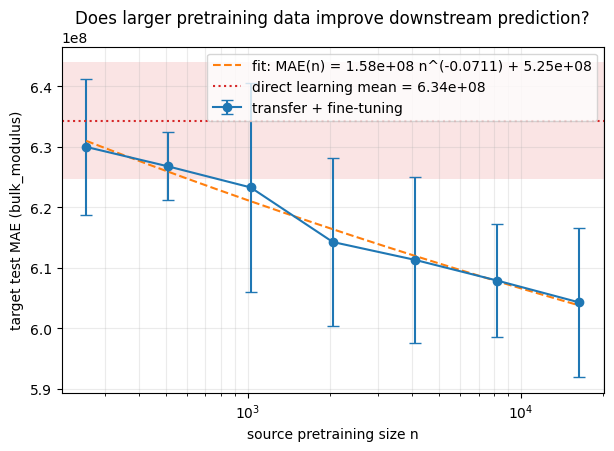

fit: MAE(n) = 1.58e+08 n^(-0.0711) + 5.25e+08


In [15]:
def power_law(n, D, alpha, C):
    return D * np.power(n, -alpha) + C

fit_text = 'power-law fit skipped'
fit_curve = None

if SCIPY_AVAILABLE and len(summary) >= 3:
    n_values = summary['n_source'].to_numpy(dtype=float)
    mae_values = summary['mae_mean'].to_numpy(dtype=float)
    y_range = max(float(mae_values.max() - mae_values.min()), 1e-8)
    p0 = [y_range * (n_values[0] ** 0.2), 0.2, max(float(mae_values.min()) * 0.8, 0.0)]
    bounds = ([0.0, 0.0, 0.0], [np.inf, 3.0, np.inf])
    try:
        popt, pcov = curve_fit(power_law, n_values, mae_values, p0=p0, bounds=bounds, maxfev=20000)
        D_hat, alpha_hat, C_hat = popt
        x_fit = np.logspace(np.log10(n_values.min()), np.log10(n_values.max()), 200)
        fit_curve = (x_fit, power_law(x_fit, *popt))
        fit_text = f'fit: MAE(n) = {D_hat:.3g} n^(-{alpha_hat:.3g}) + {C_hat:.3g}'
    except Exception as exc:
        fit_text = f'power-law fit failed: {exc}'

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    summary['n_source'],
    summary['mae_mean'],
    yerr=summary['ci90'],
    fmt='o-',
    capsize=4,
    label='transfer + fine-tuning',
)
if fit_curve is not None:
    ax.plot(fit_curve[0], fit_curve[1], '--', label=fit_text)

ax.axhline(baseline_mean, color='tab:red', linestyle=':', label=f'direct learning mean = {baseline_mean:.3g}')
if baseline_ci90 > 0:
    ax.axhspan(
        baseline_mean - baseline_ci90,
        baseline_mean + baseline_ci90,
        color='tab:red',
        alpha=0.12,
        linewidth=0,
    )

ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_xlabel('source pretraining size n')
ax.set_ylabel(f'target test MAE ({TARGET_PROPERTY})')
ax.set_title('Does larger pretraining data improve downstream prediction?')
ax.grid(True, which='both', alpha=0.25)
ax.legend()
plt.show()

print(fit_text)

In [16]:
# Summarize the effect numerically.

first = summary.iloc[0]
best = summary.loc[summary['mae_mean'].idxmin()]
last = summary.iloc[-1]

improvement_first_to_last = (first['mae_mean'] - last['mae_mean']) / first['mae_mean'] * 100
improvement_vs_direct = (baseline_mean - best['mae_mean']) / baseline_mean * 100

print(f'first n={int(first.n_source):,}: MAE={first.mae_mean:.5g}')
print(f'last  n={int(last.n_source):,}: MAE={last.mae_mean:.5g}')
print(f'best  n={int(best.n_source):,}: MAE={best.mae_mean:.5g}')
print(f'direct baseline: MAE={baseline_mean:.5g}')
print(f'improvement from first to last source size: {improvement_first_to_last:.1f}%')
print(f'improvement of best transfer vs direct: {improvement_vs_direct:.1f}%')

if improvement_first_to_last > 0:
    print('Observation: source pretraining size helped in this run.')
else:
    print('Observation: the curve was not monotonic in this quick run. Increase REPEATS/EPOCHS or use QUICK_RUN=False.')

first n=256: MAE=6.2999e+08
last  n=16,384: MAE=6.0425e+08
best  n=16,384: MAE=6.0425e+08
direct baseline: MAE=6.3431e+08
improvement from first to last source size: 4.1%
improvement of best transfer vs direct: 4.7%
Observation: source pretraining size helped in this run.


In [ ]:
# Save result tables.

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

results.to_csv(OUTPUT_DIR / 'transfer_scaling_raw_results.csv', index=False)
summary.to_csv(OUTPUT_DIR / 'transfer_scaling_summary.csv', index=False)
baseline.to_csv(OUTPUT_DIR / 'direct_learning_baseline.csv', index=False)

print(f'saved to {OUTPUT_DIR.resolve()}')

saved to /home/hamakawa/cecam_tutorial/outputs


In [ ]:
# External transfer-learning utility.
# Use this cell when you want to transfer from the PolyOmics source database to your own CSV.
# The external CSV is assumed to contain at least one SMILES column and one target-property column.

from pathlib import Path

TARGET_CSV_PATH = None  # Example: Path('my_experimental_data.csv')
EXTERNAL_TARGET_PROPERTY = 'bulk_modulus'
EXTERNAL_SMILES_COLUMN = None  # None means auto-detect from common names such as 'smiles' or 'SMILES'.
EXTERNAL_SOURCE_PROPERTY = 'density'
EXTERNAL_SOURCE_MAX_ROWS = 50000
EXTERNAL_TARGET_TEST_FRACTION = 0.2
EXTERNAL_PRETRAIN_EPOCHS = PRETRAIN_EPOCHS
EXTERNAL_FINETUNE_EPOCHS = FINETUNE_EPOCHS
EXTERNAL_BATCH_SIZE = BATCH_SIZE
EXTERNAL_SCALE_ECFP = False
EXTERNAL_RESET_HEAD = None  # None: reset when source and target property names differ.
EXTERNAL_SAVE_OUTPUTS = True


def infer_smiles_column(frame, preferred=None):
    """Choose the SMILES column in a user-provided dataframe."""
    if preferred is not None:
        if preferred not in frame.columns:
            raise ValueError(f'Preferred SMILES column {preferred!r} is not in the CSV')
        return preferred

    candidates = ['smiles']
    for col in candidates:
        if col in frame.columns:
            return col

    raise ValueError(f'Could not infer a SMILES column. Tried: {candidates}')


def build_ecfp6_matrix_from_smiles(smiles_values, desc='Calculating external ECFP6'):
    """Convert a sequence of SMILES strings into an ECFP6 matrix and a valid-row mask."""
    fps = np.full((len(smiles_values), ECFP_N_BITS), np.nan, dtype=np.float32)
    valid = np.zeros(len(smiles_values), dtype=bool)

    for i, smiles in enumerate(tqdm(smiles_values, desc=desc)):
        mol = smiles_to_mol(smiles)
        if mol is None:
            continue
        fps[i] = mol_to_ecfp6_array(mol)
        valid[i] = True

    return fps, valid


def preprocess_external_features(source_X_raw, target_train_X_raw, target_test_X_raw, scale_ecfp=False):
    """Prepare source, target-train, and target-test feature matrices with optional scaling."""
    source_X_raw = np.nan_to_num(source_X_raw, nan=0.0).astype(np.float32)
    target_train_X_raw = np.nan_to_num(target_train_X_raw, nan=0.0).astype(np.float32)
    target_test_X_raw = np.nan_to_num(target_test_X_raw, nan=0.0).astype(np.float32)

    if not scale_ecfp:
        return source_X_raw, target_train_X_raw, target_test_X_raw

    # Scaling is optional for binary fingerprints. It can help some MLPs but may amplify rare bits.
    scaler = StandardScaler()
    scaler.fit(np.vstack([source_X_raw, target_train_X_raw]))
    return (
        scaler.transform(source_X_raw).astype(np.float32),
        scaler.transform(target_train_X_raw).astype(np.float32),
        scaler.transform(target_test_X_raw).astype(np.float32),
    )


def regression_metrics(y_true, y_pred):
    """Return MAE, RMSE, and R2 for a regression prediction."""
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    denom = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = float(1.0 - np.sum((y_true - y_pred) ** 2) / denom) if denom > 0 else np.nan
    return {'mae': mae, 'rmse': rmse, 'r2': r2}


def run_external_transfer(
    target_csv_path,
    target_property,
    target_smiles_column=None,
    source_property=EXTERNAL_SOURCE_PROPERTY,
    source_max_rows=EXTERNAL_SOURCE_MAX_ROWS,
    target_test_fraction=EXTERNAL_TARGET_TEST_FRACTION,
    pretrain_epochs=EXTERNAL_PRETRAIN_EPOCHS,
    finetune_epochs=EXTERNAL_FINETUNE_EPOCHS,
    batch_size=EXTERNAL_BATCH_SIZE,
    scale_ecfp=EXTERNAL_SCALE_ECFP,
    reset_head=EXTERNAL_RESET_HEAD,
    seed=SEED,
    save_outputs=EXTERNAL_SAVE_OUTPUTS,
):
    """Pretrain on PolyOmics, fine-tune on an external CSV, and evaluate on a held-out target split."""
    target_csv_path = Path(target_csv_path)
    if not target_csv_path.exists():
        raise FileNotFoundError(target_csv_path)
    if source_property not in df.columns:
        raise ValueError(f'Source property {source_property!r} is not in the PolyOmics dataframe')

    rng = np.random.default_rng(seed)
    seed_everything(seed)

    # Source side: use the already calculated PolyOmics ECFP6 matrix X and the chosen source label.
    source_values = to_numeric_series(df[source_property])
    source_valid = source_values.notna().to_numpy() & valid_fingerprint
    source_positions = np.flatnonzero(source_valid)
    if len(source_positions) == 0:
        raise ValueError(f'No valid source rows for {source_property!r}')
    if source_max_rows is not None and len(source_positions) > source_max_rows:
        source_positions = rng.choice(source_positions, size=source_max_rows, replace=False)

    source_X_raw = X.iloc[source_positions].to_numpy(dtype=np.float32)
    source_y_raw = source_values.iloc[source_positions].to_numpy(dtype=np.float32)

    # Target side: read the user CSV, infer or use the requested SMILES column, and build ECFP6.
    target_df = pd.read_csv(target_csv_path)
    if target_property not in target_df.columns:
        raise ValueError(f'Target property {target_property!r} is not in the external CSV')
    smiles_column = infer_smiles_column(target_df, target_smiles_column)
    target_X_all, target_valid_smiles = build_ecfp6_matrix_from_smiles(
        target_df[smiles_column].to_numpy(),
        desc='Calculating target ECFP6',
    )
    target_values = to_numeric_series(target_df[target_property])
    target_valid = target_valid_smiles & target_values.notna().to_numpy()
    target_positions = np.flatnonzero(target_valid)
    if len(target_positions) < 3:
        raise ValueError(f'Need at least 3 valid target rows; found {len(target_positions)}')

    rng.shuffle(target_positions)
    n_test = max(1, int(round(len(target_positions) * target_test_fraction)))
    n_test = min(n_test, len(target_positions) - 1)
    test_positions = target_positions[:n_test]
    train_positions = target_positions[n_test:]

    target_train_X_raw = target_X_all[train_positions]
    target_test_X_raw = target_X_all[test_positions]
    target_train_y_raw = target_values.iloc[train_positions].to_numpy(dtype=np.float32)
    target_test_y_raw = target_values.iloc[test_positions].to_numpy(dtype=np.float32)

    source_X, target_train_X, target_test_X = preprocess_external_features(
        source_X_raw,
        target_train_X_raw,
        target_test_X_raw,
        scale_ecfp=scale_ecfp,
    )

    # Direct baseline: train only on the external target training set.
    direct_y_train, direct_mean, direct_std = standardize(target_train_y_raw)
    direct_model = PolymerMLP(input_dim=target_train_X.shape[1]).to(DEVICE)
    train_model(direct_model, target_train_X, direct_y_train, epochs=finetune_epochs, lr=PRETRAIN_LR, batch_size=batch_size)
    direct_pred = predict(direct_model, target_test_X) * direct_std + direct_mean

    # Transfer model: pretrain on PolyOmics source labels, then fine-tune on the external target labels.
    source_y_train, source_mean, source_std = standardize(source_y_raw)
    transfer_model = PolymerMLP(input_dim=source_X.shape[1]).to(DEVICE)
    train_model(transfer_model, source_X, source_y_train, epochs=pretrain_epochs, lr=PRETRAIN_LR, batch_size=batch_size)

    if reset_head is None:
        reset_head = source_property != target_property
    if reset_head:
        transfer_model.reset_head()
        target_y_train, target_mean, target_std = standardize(target_train_y_raw)
    else:
        target_y_train = ((target_train_y_raw - source_mean) / source_std).astype(np.float32)
        target_mean, target_std = source_mean, source_std

    train_model(transfer_model, target_train_X, target_y_train, epochs=finetune_epochs, lr=FINETUNE_LR, batch_size=batch_size)
    transfer_pred = predict(transfer_model, target_test_X) * target_std + target_mean

    metrics = pd.DataFrame([
        {'model': 'direct_target_only', **regression_metrics(target_test_y_raw, direct_pred)},
        {'model': f'transfer_{source_property}_to_{target_property}', **regression_metrics(target_test_y_raw, transfer_pred)},
    ])

    predictions = pd.DataFrame({
        'row_in_target_csv': test_positions,
        smiles_column: target_df.iloc[test_positions][smiles_column].to_numpy(),
        f'{target_property}_true': target_test_y_raw,
        f'{target_property}_pred_direct': direct_pred,
        f'{target_property}_pred_transfer': transfer_pred,
    })

    if save_outputs:
        output_dir = Path('outputs')
        output_dir.mkdir(exist_ok=True)
        stem = target_csv_path.stem
        metrics.to_csv(output_dir / f'external_transfer_{stem}_metrics.csv', index=False)
        predictions.to_csv(output_dir / f'external_transfer_{stem}_predictions.csv', index=False)
        print(f'Saved metrics and predictions to {output_dir.resolve()}')

    print(f'Source rows: {len(source_positions):,}')
    print(f'Target train rows: {len(train_positions):,}')
    print(f'Target test rows: {len(test_positions):,}')
    return {'metrics': metrics, 'predictions': predictions, 'transfer_model': transfer_model, 'direct_model': direct_model}


if TARGET_CSV_PATH is None:
    print('Set TARGET_CSV_PATH to your CSV file path, set EXTERNAL_TARGET_PROPERTY, then rerun this cell.')
    print("Example: TARGET_CSV_PATH = Path('my_experimental_data.csv')")
else:
    external_transfer_result = run_external_transfer(
        target_csv_path=TARGET_CSV_PATH,
        target_property=EXTERNAL_TARGET_PROPERTY,
        target_smiles_column=EXTERNAL_SMILES_COLUMN,
    )
    display(external_transfer_result['metrics'])
    display(external_transfer_result['predictions'].head())
